In [1]:
import os
import gzip
import json
import collections
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import bisect
import subprocess
from typing import Dict, Any, List

# --- CONFIGURATION ---
SAMPLES_CSV = "training_complete_processed_metadata.csv"
THRESHOLDS_JSON = "training_results/best_thresholds.json"
EXOME_BED_PATH = "../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed" 
BLACKLIST_BED = "../../resources/master_blacklist.bed"  
ARTEFACT_GENES_BED = "../../resources/master_blacklist.bed" 

# Load the thresholds optimized by Optuna
with open(THRESHOLDS_JSON) as f:
    config = json.load(f)
    THRESHOLDS = config["thresholds"]
    PON_FLAGS = config.get("pon_flags", {"use_cord_pon": True})

print(f"[INFO] Thresholds loaded. Analysis will evaluate {len(THRESHOLDS)} tunable features.")

[INFO] Thresholds loaded. Analysis will evaluate 34 tunable features.


In [2]:
class BedLookup:
    def __init__(self, bed_path, name):
        self.intervals = {} 
        self.name = name
        self._load_bed(bed_path)

    def _load_bed(self, bed_path):
        if not os.path.exists(bed_path):
            print(f"[WARN] BED not found: {bed_path}")
            return
        count = 0
        with open(bed_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip(): continue
                parts = line.strip().split()
                chrom, start, end = parts[0], int(parts[1]), int(parts[2])
                if chrom not in self.intervals: self.intervals[chrom] = []
                self.intervals[chrom].append((start, end))
                count += 1
        for chrom in self.intervals: self.intervals[chrom].sort(key=lambda x: x[0])
        print(f"[INFO] Loaded {count} regions for {self.name}.")

    def is_overlapped(self, chrom, pos):
        query_chrom = chrom
        if chrom not in self.intervals:
            if f"chr{chrom}" in self.intervals: query_chrom = f"chr{chrom}"
            elif chrom.startswith("chr") and chrom[3:] in self.intervals: query_chrom = chrom[3:]
            else: return False
        
        regions = self.intervals[query_chrom]
        query_idx = pos - 1 
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))
        for i in range(max(0, idx - 1), -1, -1):
            start, end = regions[i]
            if end <= query_idx: break 
            if start <= query_idx < end: return True
        return False

# Initialize Lookups
exome_lookup = BedLookup(EXOME_BED_PATH, "Exome")
cluster_lookup = BedLookup(BLACKLIST_BED, "Cluster Blacklist")

[INFO] Loaded 283942 regions for Exome.
[INFO] Loaded 4208652 regions for Cluster Blacklist.


In [3]:
def parse_vcf_to_df(vcf_path, sample_id, thresholds, exome_lookup, cluster_lookup):
    data = []
    openf = gzip.open if vcf_path.endswith(".gz") else open

    total_variants = 0
    kept_variants = 0

    with openf(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue

            total_variants += 1

            fields = line.strip().split("\t")
            chrom = fields[0]
            pos = int(fields[1])

            # --- Spatial filtering ---
            if not exome_lookup.is_overlapped(chrom, pos):
                continue
            if cluster_lookup.is_overlapped(chrom, pos):
                continue

            # Parse INFO
            info = {
                item.split("=")[0]: item.split("=")[1] if "=" in item else "Yes"
                for item in fields[7].split(";")
            }

            # --- Minimal features ---
            n_alt_sscs = int(info.get('N_ALT_SSCS', 0))
            n_total_sscs = int(info.get('N_TOTAL_SSCS', info.get('N_TOTAL', 0)))

            if n_total_sscs <= 0:
                continue

            vaf_sscs = n_alt_sscs / n_total_sscs

            # --- VAF filter ---
            if vaf_sscs > thresholds["germline_vaf_max"]:
                continue

            # Keep variant
            kept_variants += 1

            info.update({
                "CHROM": chrom,
                "POS": pos,
                "sample_id": sample_id,
                "VAF_SSCS": vaf_sscs
            })

            data.append(info)

    print(f"[INFO] {sample_id}: Total={total_variants} | Kept={kept_variants} | Removed={total_variants - kept_variants}")

    return pd.DataFrame(data)

all_dfs = []
samples_meta = pd.read_csv(SAMPLES_CSV)
for _, s in samples_meta.iterrows():
    print(f"Loading {s.sample_id}...", end="\r")
    df = parse_vcf_to_df(
    s.vcf_path,
    s.sample_id,
    THRESHOLDS,
    exome_lookup,
    cluster_lookup
)
    all_dfs.append(df)

df_raw = pd.concat(all_dfs, ignore_index=True)
# Convert numeric columns automatically
df_raw = df_raw.apply(pd.to_numeric, errors='ignore')
print(f"\n[INFO] Total variants loaded: {len(df_raw)}")

[INFO] 27YO_UDI5: Total=51268 | Kept=5954 | Removed=45314
[INFO] 27YO_UDI6: Total=53518 | Kept=7072 | Removed=46446
[INFO] UDI23_3x: Total=96901 | Kept=25023 | Removed=71878
[INFO] UDI24_3x: Total=84050 | Kept=19866 | Removed=64184
[INFO] UKCTOCS_UDI1: Total=68440 | Kept=12810 | Removed=55630
[INFO] UKCTOCS_UDI2: Total=69341 | Kept=14210 | Removed=55131
[INFO] UKCTOCS_UDI3: Total=61219 | Kept=10566 | Removed=50653
[INFO] UKCTOCS_UDI4: Total=56458 | Kept=9443 | Removed=47015
[INFO] UKCTOCS_UDI5: Total=50534 | Kept=7922 | Removed=42612
[INFO] Cordblood_D1: Total=70053 | Kept=15223 | Removed=54830
[INFO] Cordblood_H5: Total=58866 | Kept=9311 | Removed=49555
[INFO] Cordblood_H6: Total=56344 | Kept=8071 | Removed=48273
[INFO] LEGACY_I1: Total=61995 | Kept=9796 | Removed=52199
[INFO] LEGACY_I2: Total=64452 | Kept=11808 | Removed=52644
[INFO] LEGACY_I3: Total=62151 | Kept=10517 | Removed=51634
[INFO] LEGACY_I4: Total=63148 | Kept=10990 | Removed=52158
[INFO] LEGACY_I5: Total=60670 | Kept=9820

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_82793/3628898460.py:75: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_raw = df_raw.apply(pd.to_numeric, errors='ignore')



[INFO] Total variants loaded: 210522


In [4]:
def label_variant(row, thresholds, pon_flags):
    """
    Labels a variant as 1 (Pass) or 0 (Fail) and provides the first reason for failure.
    """
    # -----------------------
    # 1. Coordinate & Blacklist Checks (Spatial)
    # -----------------------
    chrom = row.get('CHROM')
    pos = row.get('POS')
    
    if not exome_lookup.is_overlapped(chrom, pos):
        return 0, "FAIL_NOT_IN_EXOME"
    if cluster_lookup.is_overlapped(chrom, pos):
        return 0, "FAIL_CLUSTER_BLACKLIST"


    # -----------------------
    # 2. Feature Extraction & Defaults
    # -----------------------
    # Basic counts
    n_alt_sscs = row.get('N_ALT_SSCS', 0)
    n_total_dcs = row.get('N_TOTAL', 0)
    n_total_sscs = row.get('N_TOTAL_SSCS', n_total_dcs)
    if n_total_sscs <= 0: n_total_sscs = n_total_dcs
    
    # Calculate VAFs early
    vaf_sscs = n_alt_sscs / n_total_sscs if n_total_sscs > 0 else 0.0
    vaf_dcs = row.get('N_ALT', 0) / n_total_dcs if n_total_dcs > 0 else 0.0

    # Quality Metrics
    asxs = row.get('AVG_ALT_ASXS', 0.0)
    mean_mapq = row.get('MEAN_ALT_MAPQ', 0.0)
    mean_baseq = row.get('MEAN_ALT_BASEQ', 0.0)
    dist_to_indel = row.get('DIST_TO_INDEL', -1)
    
    # Neighborhood / Sequence Context
    variants_20bp = row.get('VARIANTS_20BP', 0)
    variants_250bp = row.get('VARIANTS_250BP', 0)
    ref_entropy = row.get('REF_ENTROPY_40BP', 2.0)
    homopolymer_len = row.get('HOMOPOLYMER_LEN', 0)
    gc_content = row.get('GC_CONTENT', 0.5)

    # Read/Alignment Architecture
    avg_read_pos = row.get('AVG_READ_POSITION', 75.0)
    avg_alt_softclip = row.get('AVG_ALT_SOFTCLIP', 0.0)
    median_dist_softclip = row.get('MEDIAN_DIST_TO_SOFTCLIP', 1000)
    mean_insert = row.get('MEAN_INSERT', 200.0)
    avg_alt_nm = row.get('AVG_ALT_NM', 0.0)
    avg_alt_n_count = row.get('AVG_ALT_N_COUNT', 0.0)
    avg_altread_vars = row.get('AVG_ALTREAD_VARIANTS', 0.0)
    depth_percentile = row.get('DP_PERCENT', 50)

    # Strand / Position Bias
    strand_bias = row.get('STRAND_BIAS_SSCS', 0.5)
    rp_sd = row.get('RP_SD_SSCS', 0.0)
    rp_med = row.get('RP_MED_SSCS', 0.5)

    avg_nonaltread_vars = row.get("AVG_NONALTREAD_VARIANTS", 0.0)
    sd_baseq = row.get("SD_ALT_BASEQ", 0.0)
    sd_insert = row.get("SD_INSERT", 0.0)
    avg_alt_read_mean_bq = row.get("AVG_ALT_READ_MEAN_BQ", 0.0)
    mean_ref_mapq = row.get("MEAN_REF_MAPQ", 0.0)

    # Flags
    in_encode = row.get('IN_ENCODE_BLACKLIST', "No")
    in_repeatmasker = row.get('IN_REPEATMASKER', "No")
    in_cord_pon = row.get('IN_CB_PON', "No")
    in_gnomad = row.get('IN_GNOMAD_COMMON', "No")

    # -----------------------
    # 3. Filtering Logic
    # -----------------------
    
    # A. Hard/Metadata Filters
    if n_alt_sscs <= 0: return 0, "HARD_N_ALT_SSCS"
    if in_encode == "Yes": return 0, "HARD_ENCODE_BLACKLIST"
    if in_repeatmasker == "Yes": return 0, "HARD_REPEATMASKER"
    if avg_read_pos < 4 or avg_read_pos > 138: return 0, "HARD_READ_POS_EDGE"
    if pon_flags.get("use_cord_pon", False) and in_cord_pon == "Yes":
        return 0, "FAIL_CORD_PON"

    # B. Depth & Quality Filters
    if n_total_dcs < thresholds["n_total_min"]: return 0, "FAIL_MIN_DEPTH"
    if depth_percentile > thresholds["depth_percentile_max"]: return 0, "FAIL_DEPTH_PERCENTILE"
    if asxs < thresholds["asxs_min"]: return 0, "FAIL_ASXS"
    if mean_mapq < thresholds["mean_mapq_min"]: return 0, "FAIL_MAPQ"
    if mean_baseq < thresholds["mean_baseq_min"]: return 0, "FAIL_BASEQ"
    if dist_to_indel != -1 and dist_to_indel < thresholds["dist_to_indel_min"]: 
        return 0, "FAIL_DIST_TO_INDEL"

    # C. Neighborhood & Sequence Filters
    if variants_20bp > thresholds["variants_20bp_max"]: return 0, "FAIL_VARIANTS_20BP"
    if variants_250bp > thresholds["variants_250bp_max"]: return 0, "FAIL_VARIANTS_250BP"
    if ref_entropy < thresholds["ref_entropy_min"]: return 0, "FAIL_REF_ENTROPY"
    if gc_content < thresholds["gc_content_min"] or gc_content > thresholds["gc_content_max"]: 
        return 0, "FAIL_GC_CONTENT"
    if homopolymer_len > thresholds["homopolymer_len_max"]: return 0, "FAIL_HOMOPOLYMER"

    # D. Alignment Architecture Filters
    if avg_alt_softclip > thresholds["avg_alt_softclip_max"]: return 0, "FAIL_AVG_ALT_SOFTCLIP"
    if median_dist_softclip < thresholds["dist_to_softclip_min"]: return 0, "FAIL_DIST_TO_SOFTCLIP"
    if avg_alt_nm > thresholds["avg_alt_nm_max"]: return 0, "FAIL_AVG_ALT_NM"
    if avg_alt_n_count > thresholds["avg_alt_n_count_max"]: return 0, "FAIL_AVG_ALT_N_COUNT"
    if mean_insert > thresholds["mean_insert_max"]: return 0, "FAIL_MEAN_INSERT"

    if avg_nonaltread_vars > thresholds["avg_nonaltread_variants_max"]: return False, "FAIL_AVG_NONALTREAD_VARS"
    if sd_baseq > thresholds["sd_baseq_max"]: return False, "FAIL_SD_BASEQ"
    if sd_insert > thresholds["sd_insert_max"]: return False, "FAIL_SD_INSERT"
    if avg_alt_read_mean_bq < thresholds["avg_alt_read_mean_bq_min"]: return False, "FAIL_AVG_ALT_READ_MEAN_BQ"
    if mean_ref_mapq < thresholds["mean_ref_mapq_min"]: return False, "FAIL_MEAN_REF_MAPQ"

    # E. Bias & High-VAF Complexity Filters
    if n_alt_sscs >= thresholds["strand_bias_n_alt_min"]:
        if strand_bias < thresholds["strand_bias_min"] or strand_bias > thresholds["strand_bias_max"]:
            return 0, "FAIL_STRAND_BIAS"

    if n_alt_sscs >= thresholds["rp_sd_min_alt"]:
        if rp_sd < thresholds["rp_sd_min"]: return 0, "FAIL_RP_SD"
    
    if rp_med < thresholds["rp_med_min"] or rp_med > thresholds["rp_med_max"]: 
        return 0, "FAIL_RP_MED"

    is_high_avg = avg_altread_vars > thresholds["avg_altread_variants_max"]
    is_high_cond = (avg_altread_vars > thresholds["avg_altread_variants_max_for_high_vaf"]) and \
                   (vaf_dcs > thresholds["avg_altread_high_vaf_cutoff"])
    if is_high_avg or is_high_cond: return 0, "FAIL_AVG_ALTREAD_VARIANTS"

    # F. Population / VAF Filters
    if vaf_sscs > thresholds["germline_vaf_max"]: return 0, "FAIL_GERMLINE_VAF"
    if (vaf_sscs > thresholds["gnomad_vaf_cutoff"]) and (in_gnomad == "Yes"):
        return 0, "FAIL_GNOMAD_COMMON"
    
    return 1, "PASS"

# Apply labeling
print("[INFO] Labeling variants...")
labels_and_reasons = df_raw.apply(lambda row: label_variant(row, THRESHOLDS, PON_FLAGS), axis=1)
df_raw['Target'], df_raw['Reason'] = zip(*labels_and_reasons)

print(f"Labeling complete. Pass: {sum(df_raw['Target'] == 1)} | Fail: {sum(df_raw['Target'] == 0)}")

[INFO] Labeling variants...
Labeling complete. Pass: 15511 | Fail: 195011


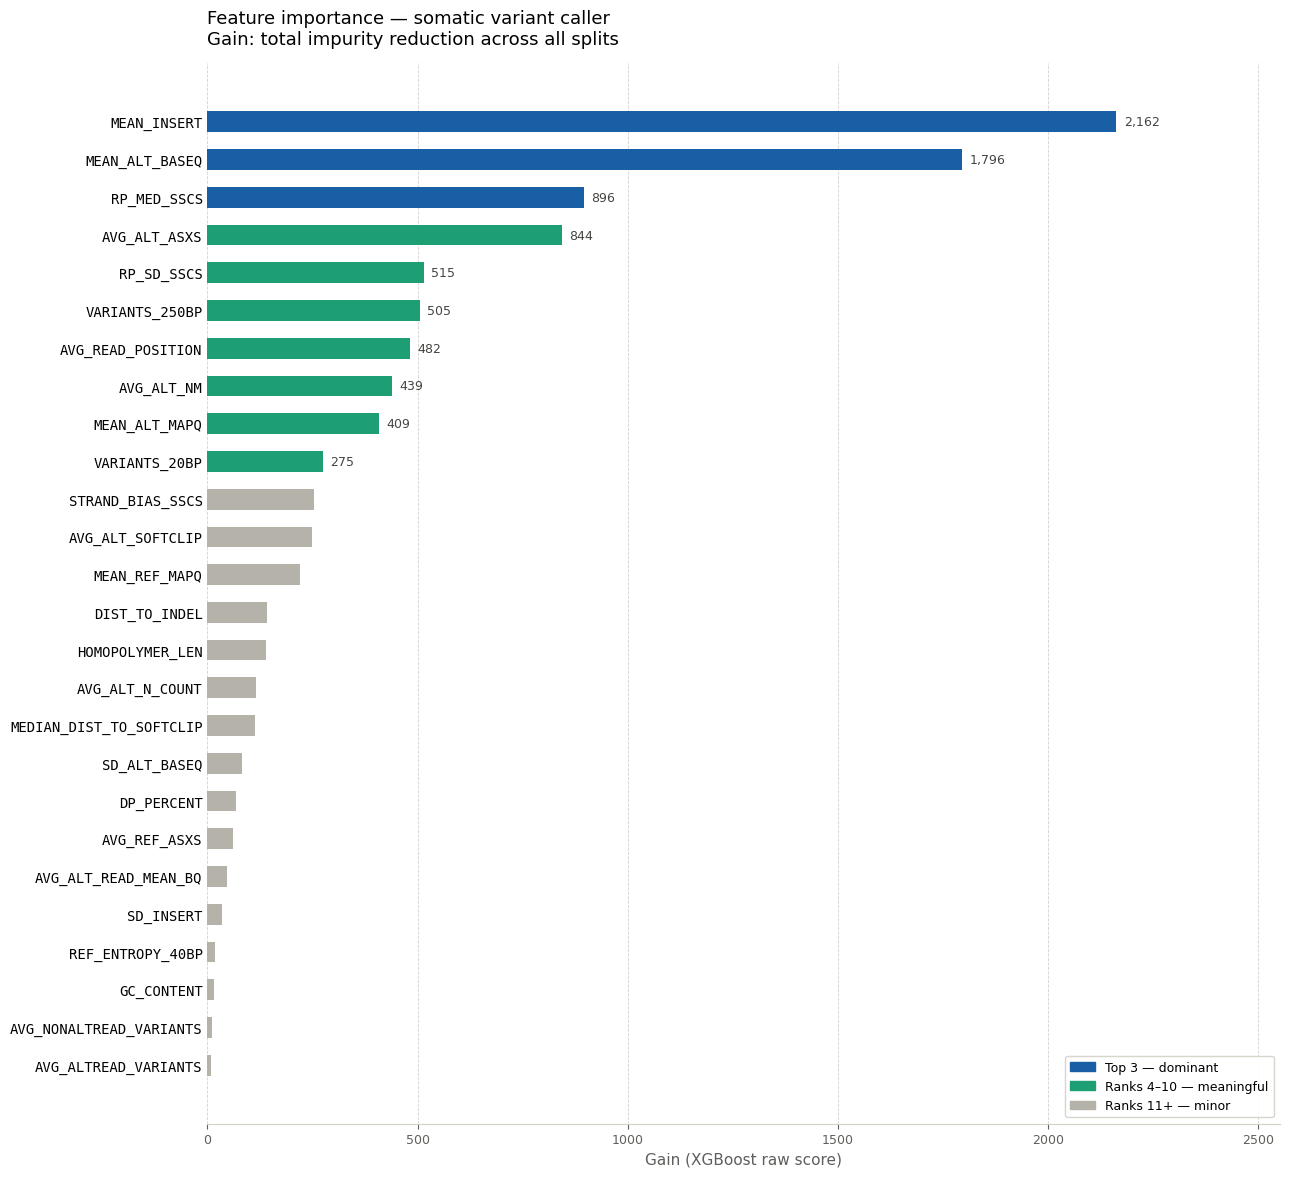

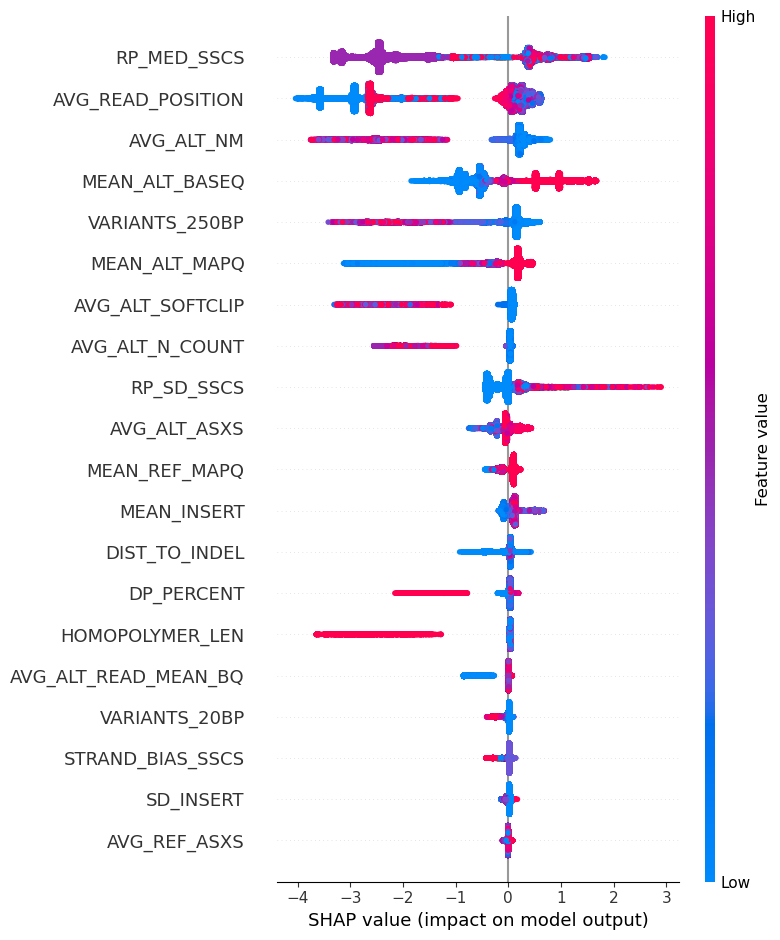

In [11]:
# =============================================================================
# Feature Importance Analysis — Final Cell
# Replaces the default xgb.plot_importance call with a polished matplotlib
# horizontal bar chart. SHAP summary plot is kept as-is.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
import shap

# --- Feature selection -----------------------------------------------------------
drop_cols = [
    'sample_id', 'CHROM', 'POS', 'Target', 'Reason',
    'VAF_DCS', 'VAF_SSCS', 'N_ALT', 'N_TOTAL', 'N_ALT_SSCS', 'N_TOTAL_SSCS',
    'IN_ENCODE_BLACKLIST', 'IN_REPEATMASKER', 'IN_CB_PON', 'IN_GNOMAD_COMMON', 'DEPTH_PERCENTILE', 'AVG_READ_LENGTH'
]
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])
X = X.select_dtypes(include=[np.number])
y = df_raw['Target']

# --- Train model -----------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
)
model.fit(X, y)

# =============================================================================
# Visualization 1 — Polished Gain Importance
# =============================================================================

# Build a sorted DataFrame of gain scores
importance_dict = model.get_booster().get_score(importance_type='gain')
imp = (
    pd.Series(importance_dict, name='gain')
    .sort_values(ascending=True)   # ascending so top feature is at the top of hbar
)

N = len(imp)

# --- Colour tiers -------------------------------------------------------
# Top 3: dominant (deep blue), next 7: meaningful (teal), rest: minor (gray)
COLOUR_TOP    = '#185FA5'   # deep blue  — top 3
COLOUR_MID    = '#1D9E75'   # teal-green — ranks 4-10
COLOUR_MINOR  = '#B4B2A9'   # warm gray  — everything else

def assign_colour(rank_from_top):
    """rank_from_top=0 is the most important feature."""
    if rank_from_top < 3:
        return COLOUR_TOP
    elif rank_from_top < 10:
        return COLOUR_MID
    else:
        return COLOUR_MINOR

# imp is sorted ascending, so index 0 = least important
colours = [assign_colour(N - 1 - i) for i in range(N)]

# --- Layout -------------------------------------------------------------
bar_height   = 0.55
fig_height   = max(8, N * 0.38 + 2.0)
fig, ax = plt.subplots(figsize=(13, fig_height))

bars = ax.barh(
    y=np.arange(N),
    width=imp.values,
    height=bar_height,
    color=colours,
    linewidth=0,
)

# Inline value labels — shown only for top 10 to avoid clutter
top10_threshold = imp.values[max(0, N - 10)]
for bar, val in zip(bars, imp.values):
    if val >= top10_threshold:
        ax.text(
            val + imp.values.max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}',
            va='center', ha='left',
            fontsize=9, color='#444441',
        )

# Feature name labels
ax.set_yticks(np.arange(N))
ax.set_yticklabels(imp.index, fontsize=10, fontfamily='monospace')

# Axes styling
ax.set_xlabel('Gain (XGBoost raw score)', fontsize=11, color='#5F5E5A')
ax.set_title(
    "Feature importance — somatic variant caller\n"
    "Gain: total impurity reduction across all splits",
    fontsize=13, fontweight='normal', pad=14, loc='left',
)
ax.tick_params(axis='x', labelsize=9, colors='#5F5E5A')
ax.tick_params(axis='y', length=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#D3D1C7')
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

# Extend x-axis so inline labels don't clip
ax.set_xlim(0, imp.values.max() * 1.18)

# Legend
legend_handles = [
    mpatches.Patch(color=COLOUR_TOP,   label='Top 3 — dominant'),
    mpatches.Patch(color=COLOUR_MID,   label='Ranks 4–10 — meaningful'),
    mpatches.Patch(color=COLOUR_MINOR, label='Ranks 11+ — minor'),
]
ax.legend(
    handles=legend_handles,
    loc='lower right',
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    edgecolor='#D3D1C7',
)

plt.tight_layout()
plt.savefig('feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Visualization 2 — SHAP Directionality (unchanged)
# =============================================================================

explainer  = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

<Axes: title={'center': 'Primary Reasons for Failure'}, ylabel='Reason'>

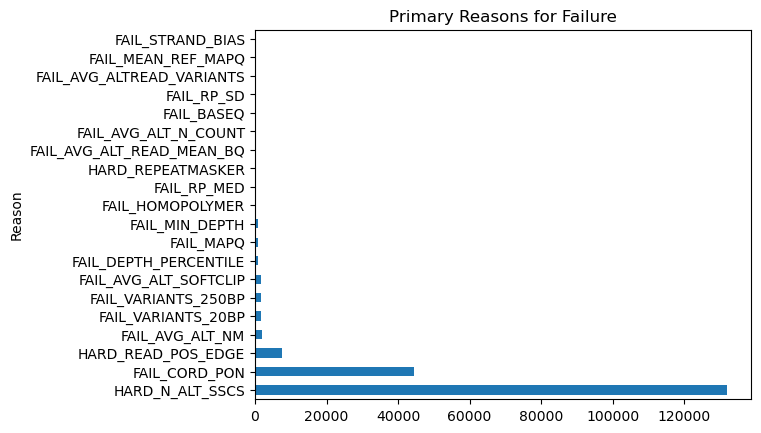

In [6]:
# Count how many variants failed for each specific reason
reason_counts = df_raw[df_raw['Target'] == 0]['Reason'].value_counts()

# Plot it
reason_counts.plot(kind='barh', title="Primary Reasons for Failure")

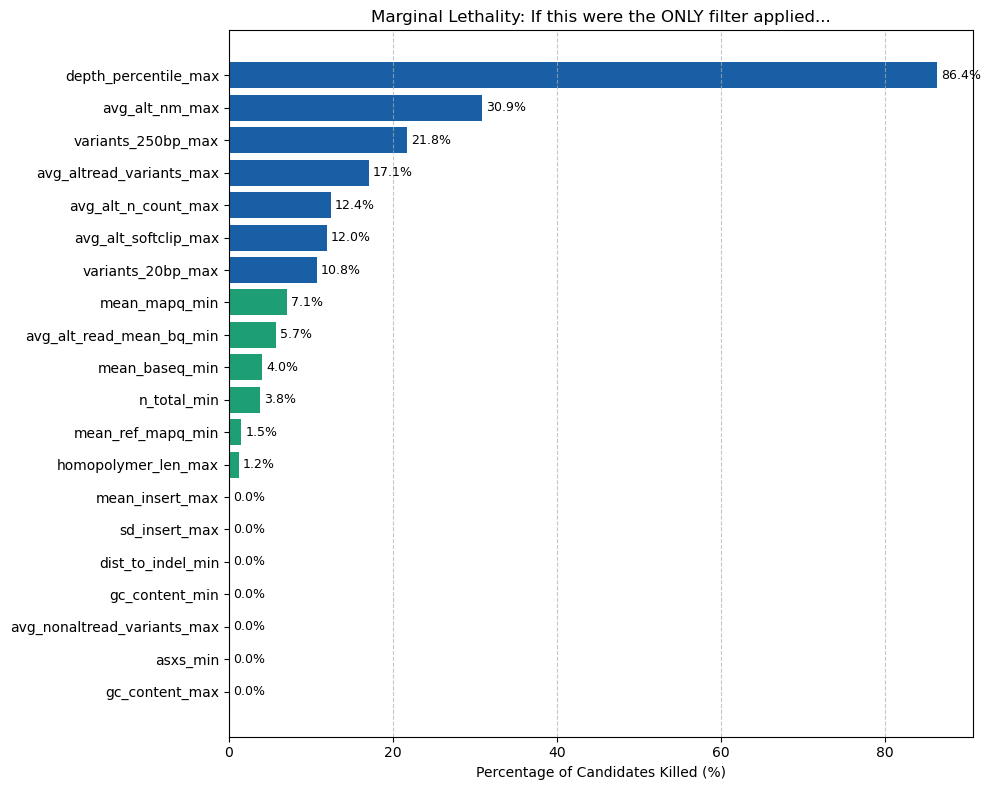

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

marginal_counts = {}
total_candidates = len(df_raw)

for key, threshold in THRESHOLDS.items():
    # Identify the feature name from the threshold key
    # Handles keys like 'asxs_min' -> 'AVG_ALT_ASXS' or 'mean_insert_max' -> 'MEAN_INSERT'
    feature_mapping = {
        "asxs": "AVG_ALT_ASXS",
        "mean_mapq": "MEAN_ALT_MAPQ",
        "mean_baseq": "MEAN_ALT_BASEQ",
        "mean_insert": "MEAN_INSERT",
        "variants_20bp": "VARIANTS_20BP",
        # ... add other mappings as needed based on your column names
    }
    
    # Try to extract base name
    base_name = key.replace("_min", "").replace("_max", "")
    col_name = feature_mapping.get(base_name, base_name.upper())

    if col_name in df_raw.columns:
        if "_max" in key:
            fail_mask = df_raw[col_name] > threshold
        elif "_min" in key:
            fail_mask = df_raw[col_name] < threshold
        else:
            continue
            
        marginal_counts[key] = fail_mask.sum()

# Convert to DataFrame for easier plotting
df_marginal = pd.DataFrame.from_dict(marginal_counts, orient='index', columns=['FailCount'])
df_marginal['FailPercent'] = (df_marginal['FailCount'] / total_candidates) * 100
df_marginal = df_marginal.sort_values(by='FailCount', ascending=True)

# --- Plotting ---
plt.figure(figsize=(10, 8))
colors = ['#1D9E75' if x < 10 else '#185FA5' for x in df_marginal['FailPercent']]

bars = plt.barh(df_marginal.index, df_marginal['FailPercent'], color=colors)
plt.xlabel('Percentage of Candidates Killed (%)')
plt.title('Marginal Lethality: If this were the ONLY filter applied...')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

<Axes: >

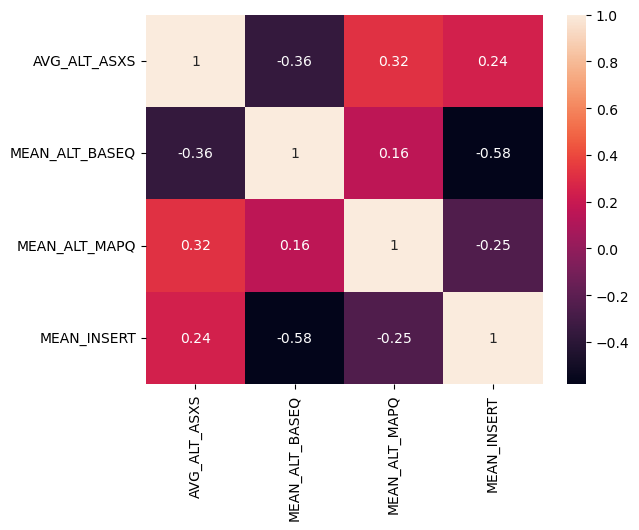

In [9]:
import seaborn as sns
cols_to_check = ['AVG_ALT_ASXS', 'MEAN_ALT_BASEQ', 'MEAN_ALT_MAPQ', 'MEAN_INSERT']
sns.heatmap(df_raw[cols_to_check].corr(), annot=True)

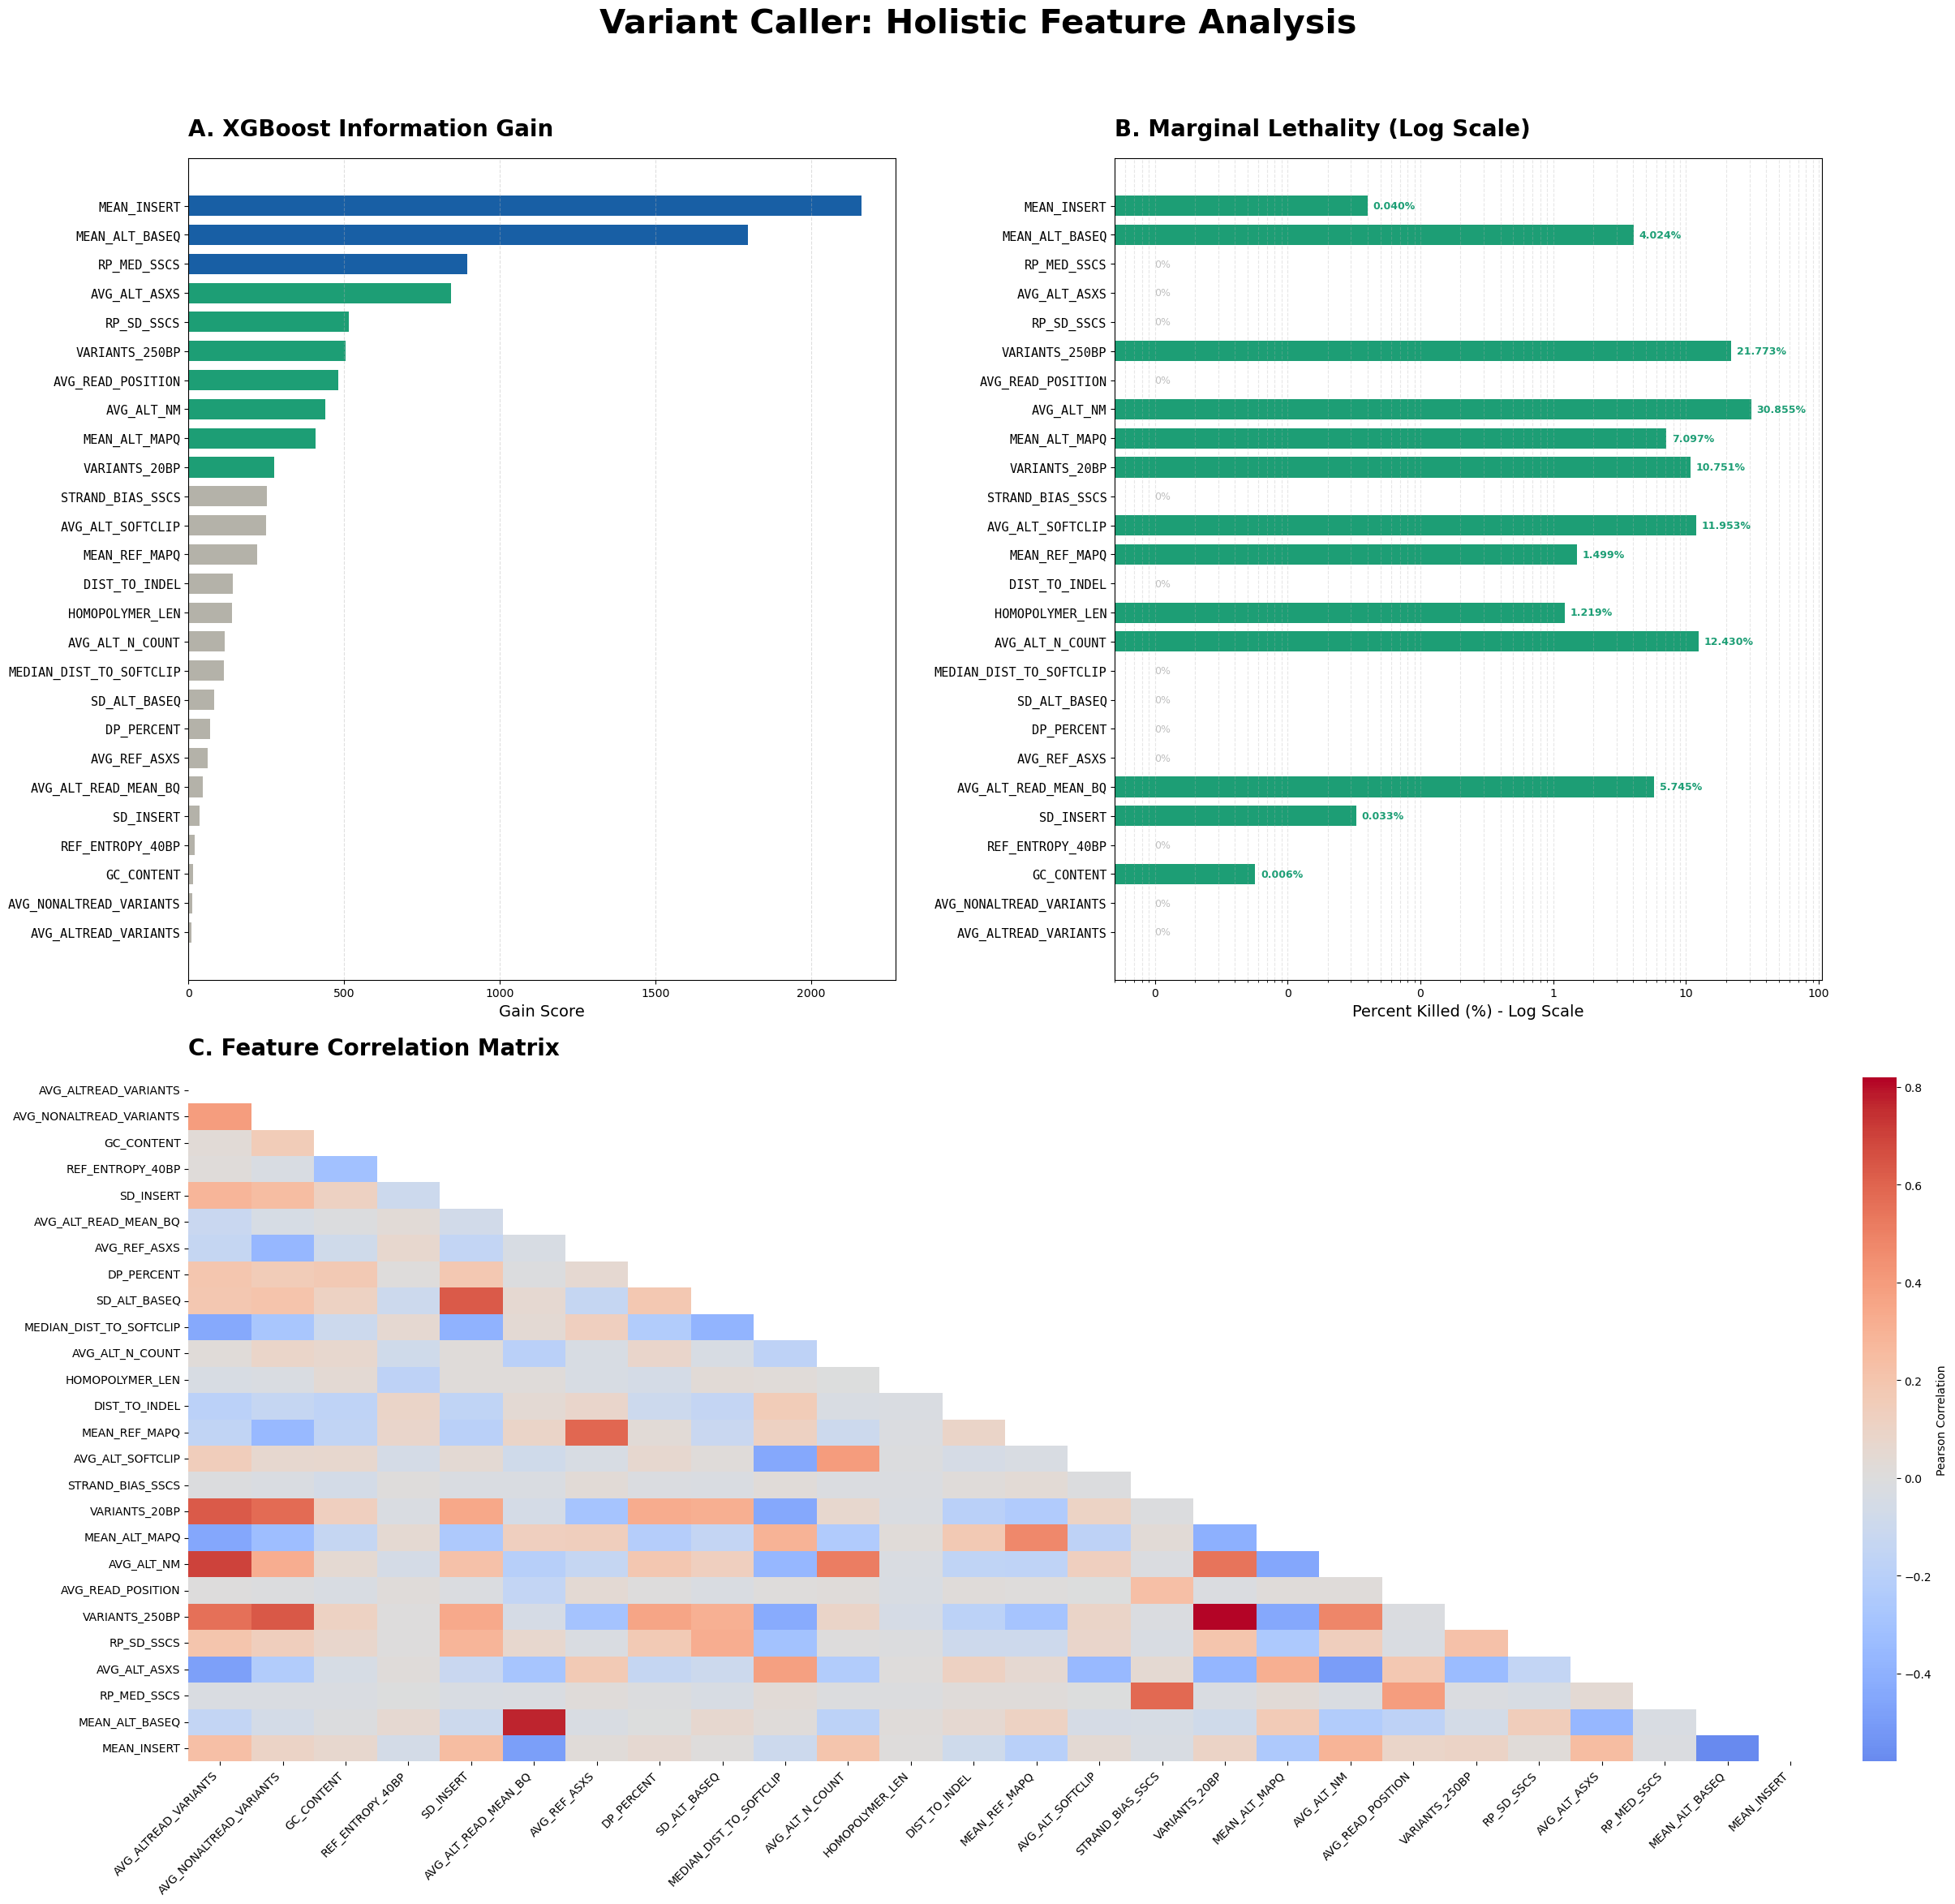

In [19]:
import matplotlib.ticker as ticker

# ... (Previous analysis code remains the same) ...

# =============================================================================
# 4. Final Plotting (Log-Scale Symmetry)
# =============================================================================
fig = plt.figure(figsize=(24, 22), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

# --- PANEL A (Left): XGBoost Gain ---
ax1 = fig.add_subplot(gs[0, 0])
# (Styling remains the same as previous)
ax1.barh(y=np.arange(N), width=df_gain.values, color=colours, height=0.7)
ax1.set_yticks(np.arange(N))
ax1.set_yticklabels(master_feature_list, fontfamily='monospace', fontsize=11)
ax1.set_title("A. XGBoost Information Gain", loc='left', fontsize=20, fontweight='bold', pad=20)
ax1.set_xlabel("Gain Score", fontsize=14)
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# --- PANEL B (Right): Marginal Lethality (LOG SCALE) ---
ax2 = fig.add_subplot(gs[0, 1])

# We use a log scale, but we need to handle the 0s
# We'll plot the actual values but set the scale to symlog or log
# 'Log' scale is better for showing orders of magnitude
ax2.set_xscale('log')

# Plot bars - adding a tiny offset for 0s so they appear on the axis
lethality_values = df_lethality.values
ax2.barh(y=np.arange(N), width=lethality_values, color='#1D9E75', height=0.7)

ax2.set_yticks(np.arange(N))
ax2.set_yticklabels(master_feature_list, fontfamily='monospace', fontsize=11)
ax2.set_title("B. Marginal Lethality (Log Scale)", loc='left', fontsize=20, fontweight='bold', pad=20)
ax2.set_xlabel("Percent Killed (%) - Log Scale", fontsize=14)

# Add text labels so small numbers are visible
for i, val in enumerate(lethality_values):
    if val > 0:
        ax2.text(val * 1.1, i, f'{val:.3f}%', va='center', fontsize=9, color='#1D9E75', fontweight='bold')
    else:
        ax2.text(0.001, i, '0%', va='center', fontsize=9, color='gray', alpha=0.5)

# Set reasonable limits for the log scale (e.g., from 0.001% to 100%)
ax2.set_xlim(0.0005, 105) 
ax2.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.grid(axis='x', which='both', linestyle='--', alpha=0.3)

# --- PANEL C (Bottom): Full-Width Correlation Matrix ---
ax3 = fig.add_subplot(gs[1, :])
corr_matrix = X[master_feature_list].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            annot=False, ax=ax3, square=False, 
            cbar_kws={"label": "Pearson Correlation", "pad": 0.02})

ax3.set_title("C. Feature Correlation Matrix", loc='left', fontsize=20, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

plt.suptitle("Variant Caller: Holistic Feature Analysis", fontsize=30, fontweight='bold', y=1.06)
plt.show()

In [21]:
# Pick one of the '0%' filters, e.g., 'AVG_ALT_NM'
feature = "RP_MED_SSCS"
threshold = 0.9861037895535609 # or whatever is in your THRESHOLDS dict

print(f"Max value in data: {df_raw[feature].max()}")
print(f"Min value in data: {df_raw[feature].min()}")
print(f"Number of variants > threshold: {(df_raw[feature] < threshold).sum()}")

Max value in data: 0.993
Min value in data: 0.0
Number of variants > threshold: 206541


<Figure size 2600x2400 with 0 Axes>

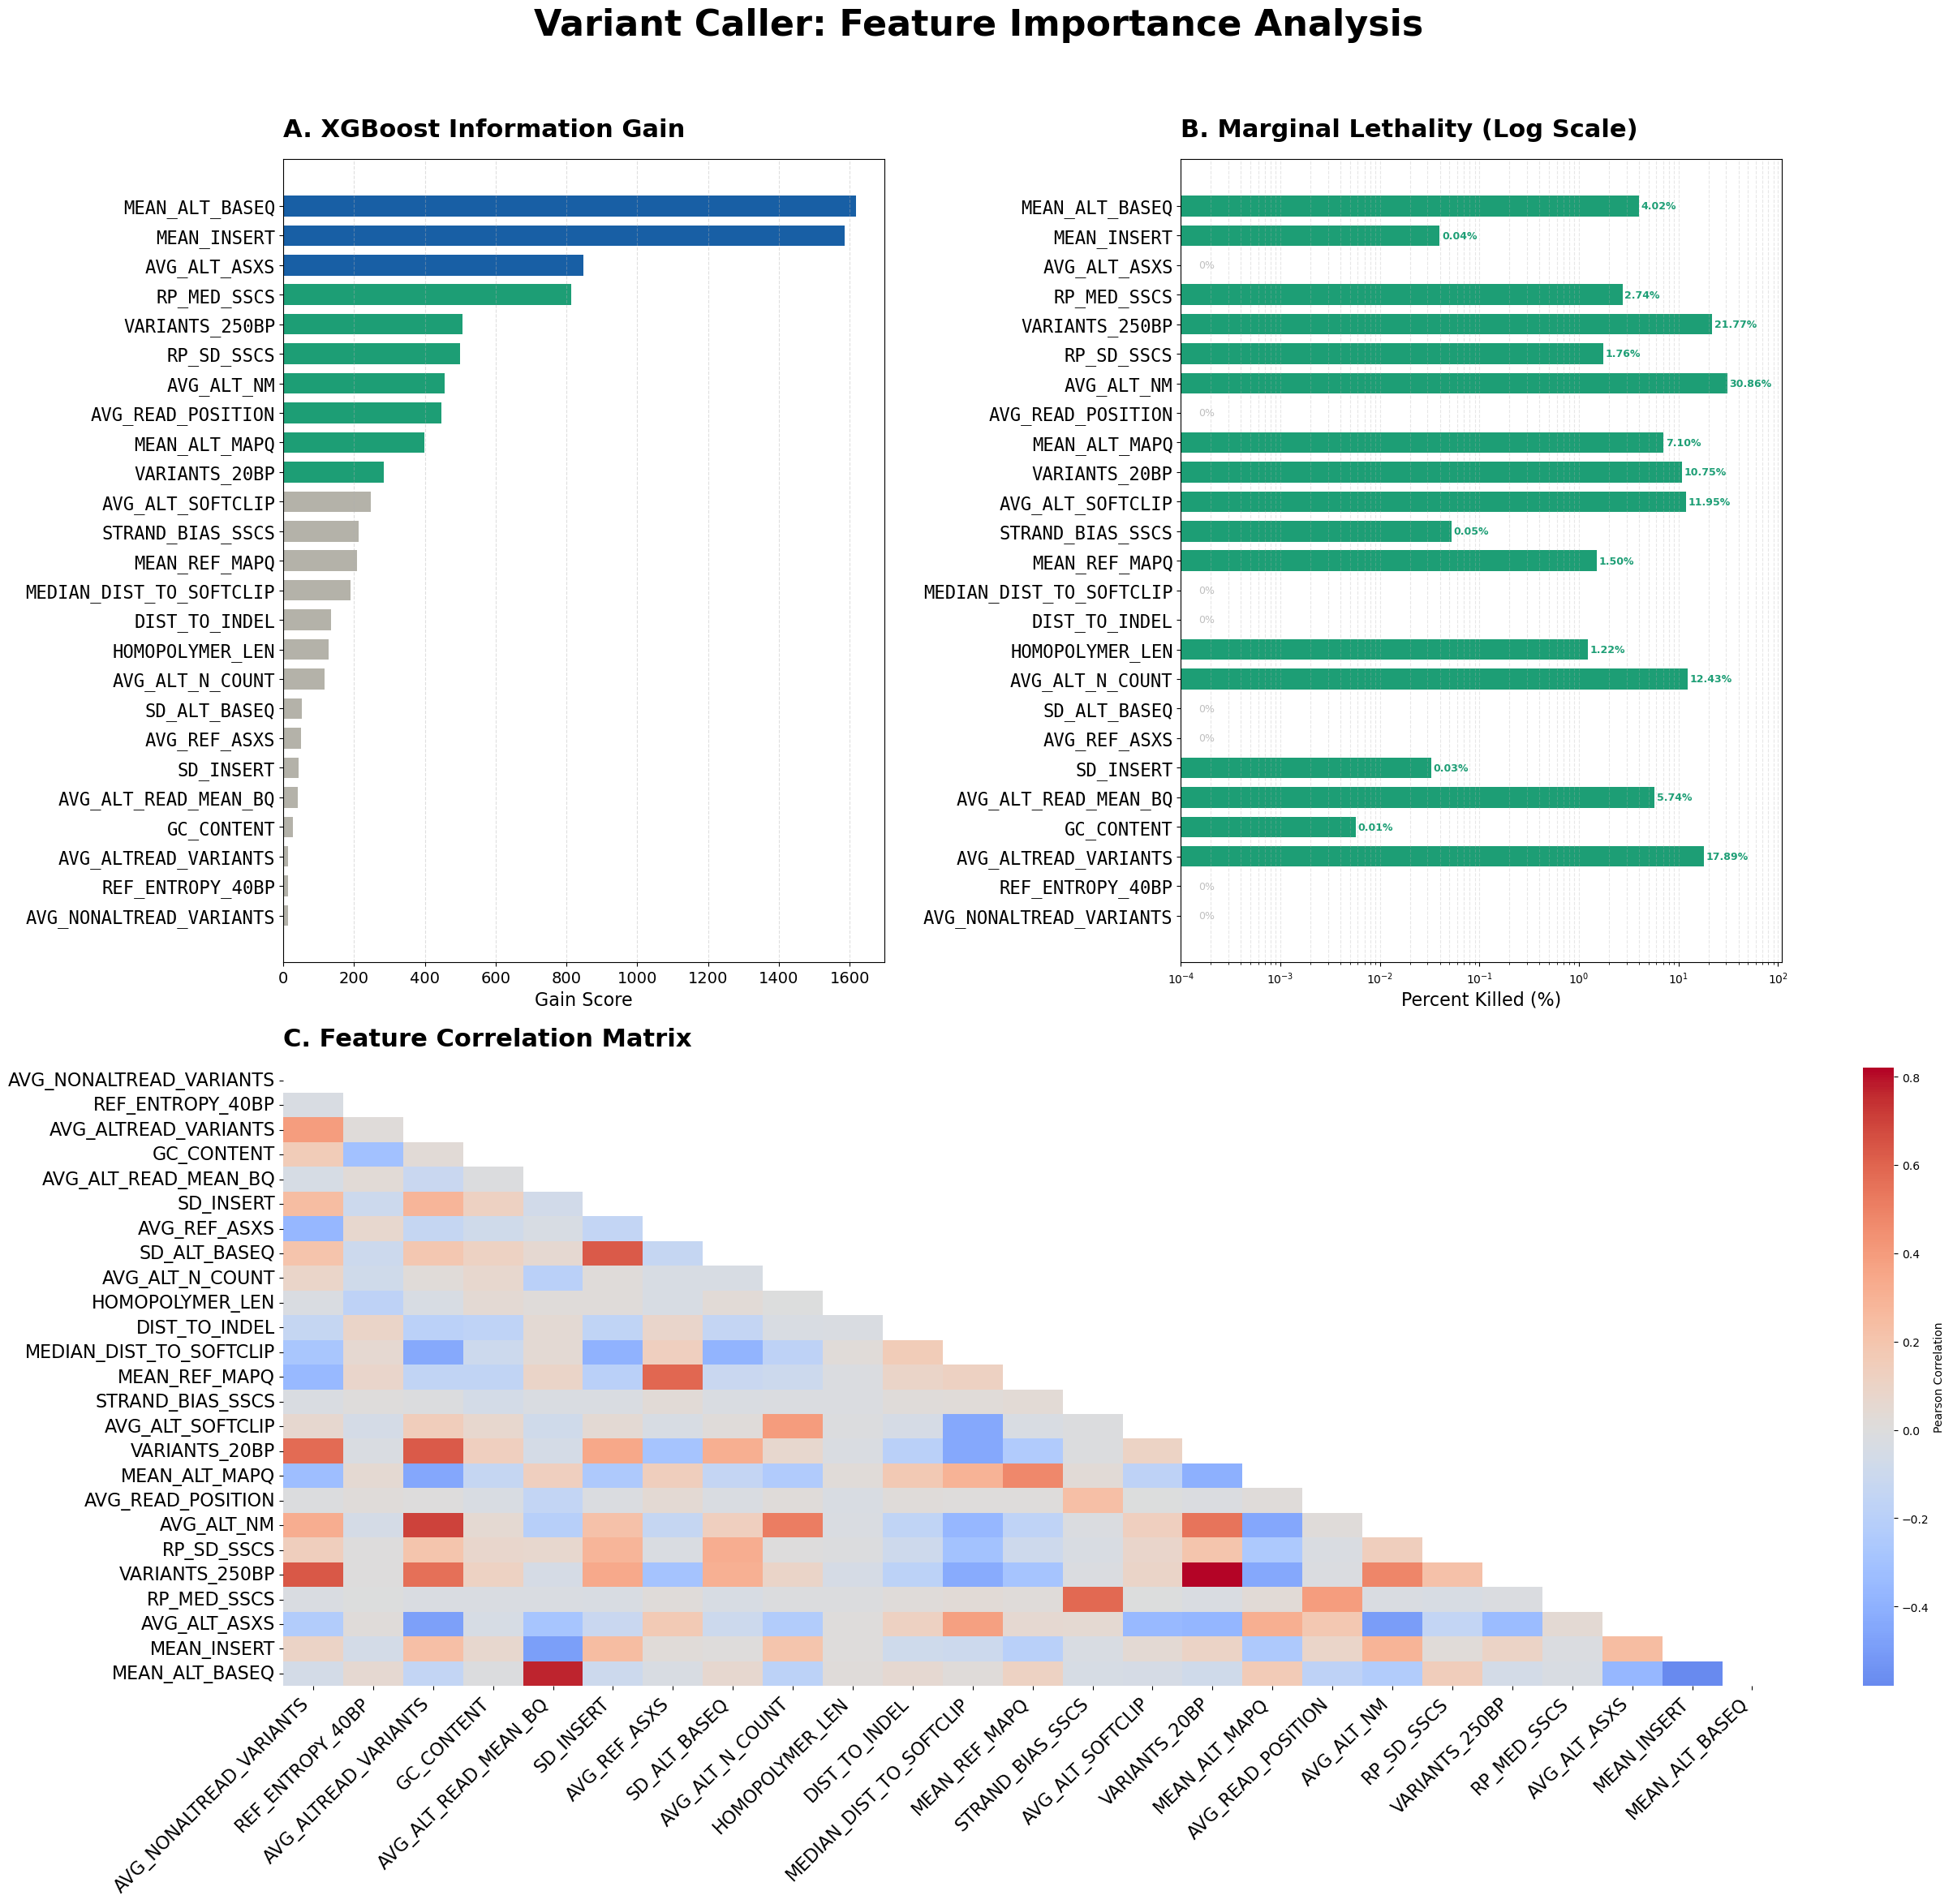

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import matplotlib.ticker as ticker

LABEL_SIZE = 16    # Feature names
TITLE_SIZE = 22    # Subplot titles (A, B, C)
SUPTITLE_SIZE = 32 # Main title
TICKS_SIZE = 14    # Axis numbers/scales

fig = plt.figure(figsize=(26, 24), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1])

# =============================================================================
# 1. XGBoost Importance (The "Master" Order)
# =============================================================================
# Standard prep: dropping non-numeric/metadata columns
drop_cols = [
    'sample_id', 'CHROM', 'POS', 'Target', 'Reason',
    'VAF_DCS', 'VAF_SSCS', 'N_ALT', 'N_TOTAL', 'N_ALT_SSCS', 'N_TOTAL_SSCS',
    'IN_ENCODE_BLACKLIST', 'IN_REPEATMASKER', 'IN_CB_PON', 'IN_GNOMAD_COMMON', 'DEPTH_PERCENTILE', 'AVG_READ_LENGTH', "DP_PERCENT"
]
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])
X = X.select_dtypes(include=[np.number])
y = df_raw['Target']

model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X, y)

# Get gain importance and set the Master Order for the plots
df_gain = pd.Series(model.get_booster().get_score(importance_type='gain')).sort_values(ascending=True)
master_feature_list = df_gain.index
N = len(df_gain)

# =============================================================================
# 2. Marginal Lethality (Using Your Actual Logic Blocks)
# =============================================================================
# We define each filter logic exactly as it appears in your label_variant code
# 'r' is a row of data, 't' is your THRESHOLDS dictionary
logic_blocks = {
    "AVG_ALT_ASXS": lambda r, t: r['AVG_ALT_ASXS'] < t['asxs_min'],
    "MEAN_ALT_MAPQ": lambda r, t: r['MEAN_ALT_MAPQ'] < t['mean_mapq_min'],
    "MEAN_ALT_BASEQ": lambda r, t: r['MEAN_ALT_BASEQ'] < t['mean_baseq_min'],
    "VARIANTS_20BP": lambda r, t: r['VARIANTS_20BP'] > t['variants_20bp_max'],
    "VARIANTS_250BP": lambda r, t: r['VARIANTS_250BP'] > t['variants_250bp_max'],
    "REF_ENTROPY_40BP": lambda r, t: r['REF_ENTROPY_40BP'] < t['ref_entropy_min'],
    "GC_CONTENT": lambda r, t: (r['GC_CONTENT'] < t['gc_content_min']) or (r['GC_CONTENT'] > t['gc_content_max']),
    "HOMOPOLYMER_LEN": lambda r, t: r['HOMOPOLYMER_LEN'] > t['homopolymer_len_max'],
    "AVG_ALT_SOFTCLIP": lambda r, t: r['AVG_ALT_SOFTCLIP'] > t['avg_alt_softclip_max'],
    "MEDIAN_DIST_TO_SOFTCLIP": lambda r, t: r['MEDIAN_DIST_TO_SOFTCLIP'] < t['dist_to_softclip_min'],
    "AVG_ALT_NM": lambda r, t: r['AVG_ALT_NM'] > t['avg_alt_nm_max'],
    "AVG_ALT_N_COUNT": lambda r, t: r['AVG_ALT_N_COUNT'] > t['avg_alt_n_count_max'],
    "MEAN_INSERT": lambda r, t: r['MEAN_INSERT'] > t['mean_insert_max'],
    "AVG_NONALTREAD_VARIANTS": lambda r, t: r['AVG_NONALTREAD_VARIANTS'] > t['avg_nonaltread_variants_max'],
    "SD_ALT_BASEQ": lambda r, t: r['SD_ALT_BASEQ'] > t['sd_baseq_max'],
    "SD_INSERT": lambda r, t: r['SD_INSERT'] > t['sd_insert_max'],
    "AVG_ALT_READ_MEAN_BQ": lambda r, t: r['AVG_ALT_READ_MEAN_BQ'] < t['avg_alt_read_mean_bq_min'],
    "MEAN_REF_MAPQ": lambda r, t: r['MEAN_REF_MAPQ'] < t['mean_ref_mapq_min'],
    "STRAND_BIAS_SSCS": lambda r, t: (r['N_ALT_SSCS'] >= t['strand_bias_n_alt_min']) and \
                                     ((r['STRAND_BIAS_SSCS'] < t['strand_bias_min']) or (r['STRAND_BIAS_SSCS'] > t['strand_bias_max'])),
    "RP_SD_SSCS": lambda r, t: (r['N_ALT_SSCS'] >= t['rp_sd_min_alt']) and (r['RP_SD_SSCS'] < t['rp_sd_min']),
    "RP_MED_SSCS": lambda r, t: (r['RP_MED_SSCS'] < t['rp_med_min']) or (r['RP_MED_SSCS'] > t['rp_med_max']),
    "AVG_ALTREAD_VARIANTS": lambda r, t: (r['AVG_ALTREAD_VARIANTS'] > t['avg_altread_variants_max']) or \
                                         ((r['AVG_ALTREAD_VARIANTS'] > t['avg_altread_variants_max_for_high_vaf']) and \
                                          ((r['N_ALT'] / r['N_TOTAL']) > t['avg_altread_high_vaf_cutoff']))
}

marginal_counts = {}
for feat_name, logic_func in logic_blocks.items():
    if feat_name in df_raw.columns:
        # Apply the logic function to every row in df_raw independently
        fail_count = df_raw.apply(lambda row: logic_func(row, THRESHOLDS), axis=1).sum()
        marginal_counts[feat_name] = (fail_count / len(df_raw)) * 100

# Reindex lethality to match the XGBoost feature order (master_feature_list)
df_lethality = pd.Series(marginal_counts).reindex(master_feature_list).fillna(0)

# =============================================================================
# 3. Final Plotting (Perfect Symmetry)
# =============================================================================
fig = plt.figure(figsize=(24, 22), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1])

# --- PANEL A (Left): XGBoost Gain ---
ax1 = fig.add_subplot(gs[0, 0])
COLOUR_TOP, COLOUR_MID, COLOUR_MINOR = '#185FA5', '#1D9E75', '#B4B2A9'
colours = [COLOUR_TOP if (N-1-i) < 3 else (COLOUR_MID if (N-1-i) < 10 else COLOUR_MINOR) for i in range(N)]
ax1.barh(y=np.arange(N), width=df_gain.values, color=colours, height=0.7)
ax1.set_yticks(np.arange(N))
ax1.set_yticklabels(master_feature_list, fontfamily='monospace', fontsize=LABEL_SIZE)
ax1.set_title("A. XGBoost Information Gain", loc='left', fontsize=TITLE_SIZE, fontweight='bold', pad=20)
ax1.tick_params(axis='x', labelsize=TICKS_SIZE)
ax1.set_xlabel("Gain Score", fontsize=LABEL_SIZE)
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# --- PANEL B (Right): Marginal Lethality (Log Scale) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_xscale('log')
ax2.barh(y=np.arange(N), width=df_lethality.values, color='#1D9E75', height=0.7)
ax2.set_yticks(np.arange(N))
ax2.set_yticklabels(master_feature_list, fontfamily='monospace', fontsize=LABEL_SIZE)
ax2.set_title("B. Marginal Lethality (Log Scale)", loc='left', fontsize=TITLE_SIZE, fontweight='bold', pad=20)
ax2.set_xlabel("Percent Killed (%)", fontsize=LABEL_SIZE)

# Add clear text labels for the bars
for i, val in enumerate(df_lethality.values):
    if val > 0:
        ax2.text(val * 1.05, i, f'{val:.2f}%', va='center', fontsize=9, fontweight='bold', color='#1D9E75')
    else:
        ax2.text(0.00015, i, '0%', va='center', fontsize=9, color='gray', alpha=0.5)

ax2.set_xlim(0.0001, 110)
ax2.grid(axis='x', which='both', linestyle='--', alpha=0.3)

# --- PANEL C (Bottom): Full-Width Correlation Matrix ---
ax3 = fig.add_subplot(gs[1, :])
corr_matrix = X[master_feature_list].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, annot=False, ax=ax3, square=False, cbar_kws={"label": "Pearson Correlation"})
# Make heatmap tick labels bigger
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=LABEL_SIZE)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize=LABEL_SIZE)

ax3.set_title("C. Feature Correlation Matrix", loc='left', fontsize=TITLE_SIZE, fontweight='bold', pad=20)

# Main Super Title
plt.suptitle("Variant Caller: Feature Importance Analysis", fontsize=SUPTITLE_SIZE, fontweight='bold', y=1.06)
plt.show()